## Problem Statement 
The objective of this project is to analyze customer purchasing behavior using transaction data to identify high-value customers, segment them based on their contribution to revenue, and provide actionable insights to improve customer retention and overall business profitability.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_excel('Online Retail.xlsx')

In [3]:
df.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


##### Raw Data is dirty and not usable directly.

In [6]:
# Removing missing customer
df = df.dropna(subset=['CustomerID'])

In [7]:
#Removing Cancelled Invoices
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [8]:
# Removing negative or Zero Quantity
df = df[df['Quantity'] > 0]

In [9]:
# Removing negative or Zero Price
df = df[df['UnitPrice'] > 0]

In [10]:
# Creating Revenue Column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [11]:
# Converting Customer ID to Int
df['CustomerID'] = df['CustomerID'].astype(int)

In [12]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue
count,397884.000000,397884,397884.000000,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023360,3.116488,15294.423453,22.397000
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,179.331775,NaN,22.097877,1713.141560,309.071041


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  int64         
 7   Country      397884 non-null  object        
 8   Revenue      397884 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 30.4+ MB


## Customer Aggregation

In [15]:
customer_df = df.groupby('CustomerID').agg({
    'InvoiceDate': ['min', 'max'],
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
}).reset_index()

customer_df.columns = [
    'CustomerID',
    'first_purchase',
    'last_purchase',
    'total_orders',
    'total_spent'
]

In [16]:
customer_df.head()

,CustomerID,first_purchase,last_purchase,total_orders,total_spent
0,12346,2011-01-18 10:01:00,2011-01-18 10:01:00,1,77183.60
1,12347,2010-12-07 14:57:00,2011-12-07 15:52:00,7,4310.00
2,12348,2010-12-16 19:09:00,2011-09-25 13:13:00,4,1797.24
3,12349,2011-11-21 09:51:00,2011-11-21 09:51:00,1,1757.55
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40


In [17]:
customer_df.shape

(4338, 5)

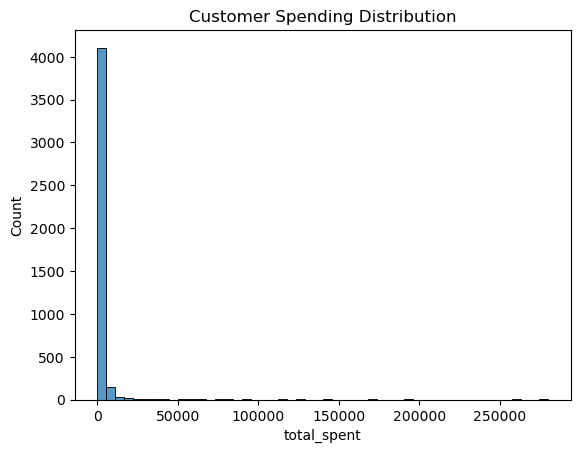

In [28]:
sns.histplot(customer_df['total_spent'], bins=50)
plt.title("Customer Spending Distribution")
plt.show()

##### The distribution of customer spending is highly right-skewed, indicating that a small number of customers contribute significantly higher revenue compared to the majority.

## Insight
- Aggregating transaction-level data to customer-level highlights variations in customer behavior, where some customers contribute significantly more revenue than others.

In [21]:
import datetime as dt
today = customer_df['last_purchase'].max()

In [22]:
customer_df['recency'] = (today - customer_df['last_purchase']).dt.days
customer_df['frequency'] = customer_df['total_orders']
customer_df['monetary'] = customer_df['total_spent']

In [23]:
customer_df[['recency','frequency','monetary']].head()

,recency,frequency,monetary
0,325,1,77183.60
1,1,7,4310.00
2,74,4,1797.24
3,18,1,1757.55
4,309,1,334.40


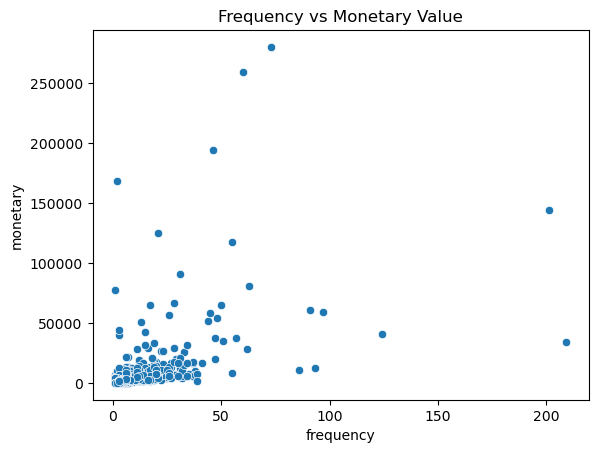

In [29]:
sns.scatterplot(x='frequency', y='monetary', data=customer_df)
plt.title("Frequency vs Monetary Value")
plt.show()

##### The positive relationship between purchase frequency and monetary value shows that customers who purchase more frequently tend to spend more, indicating strong customer loyalty.

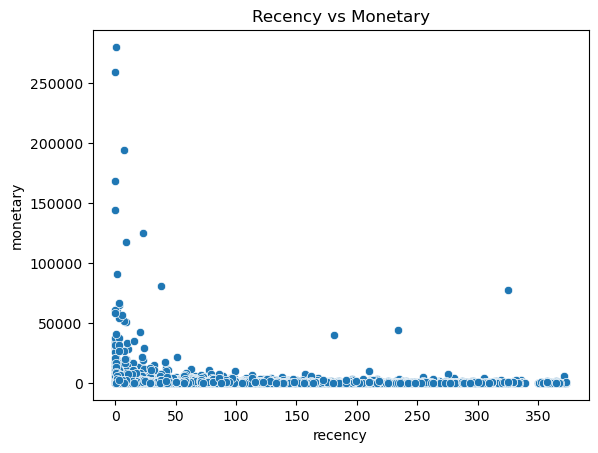

In [30]:
sns.scatterplot(x='recency', y='monetary', data=customer_df)
plt.title("Recency vs Monetary")
plt.show()

##### Customers with lower recency values (recent buyers) tend to have higher spending, while customers with high recency are less engaged and likely to churn.

## Insights
- Customers show varying recency values, indicating a mix of active and inactive users.
- A large number of customers have low purchase frequency, suggesting many are one-time buyers.
- Customers with higher monetary value tend to have higher purchase frequency, indicating stronger engagement.
- Customers with high recency and low frequency are at high risk of churn.

In [24]:
customer_df['segment'] = pd.qcut(customer_df['monetary'], 3, labels=['Low', 'Medium', 'High'])

In [25]:
customer_df['segment'].value_counts()

segment
Low       1446
Medium    1446
High      1446
Name: count, dtype: int64

<Axes: xlabel='segment'>

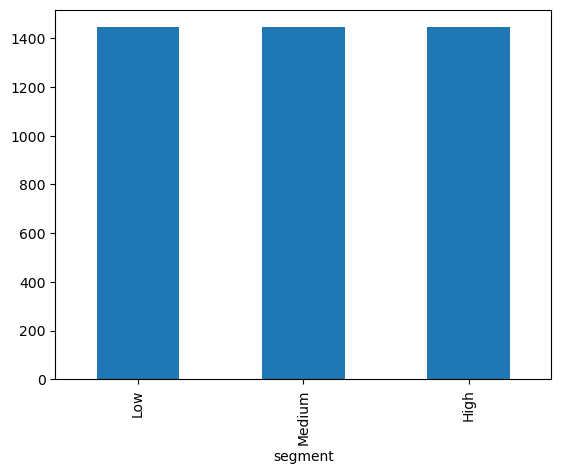

In [26]:
customer_df['segment'].value_counts().plot(kind='bar')

##### The customer base is evenly distributed across low, medium, and high-value segments due to quantile-based segmentation. This enables meaningful comparison of customer behavior across different segments.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_2372\3802702558.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  customer_df.groupby('segment')['monetary'].sum().plot(kind='bar')


<Axes: xlabel='segment'>

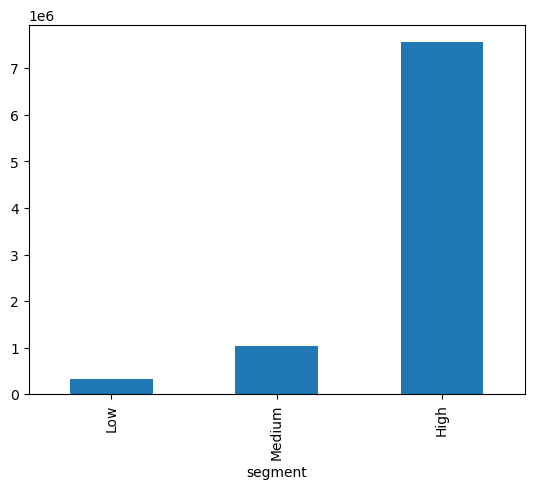

In [27]:
customer_df.groupby('segment')['monetary'].sum().plot(kind='bar')

##### The revenue contribution varies significantly across customer segments, with high-value customers contributing the largest share of total revenue despite having the same number of customers as other segments. This highlights the importance of focusing on high-value customers for maximizing business revenue

In [33]:
# Top 20 customers Revenue Contribution
top_20 = customer_df.sort_values(by='monetary', ascending=False).head(int(0.2 * len(customer_df)))
top_20_revenue = top_20['monetary'].sum()
total_revenue = customer_df['monetary'].sum()

print("Top 20% customers contribute:", (top_20_revenue / total_revenue) * 100, "% revenue")

Top 20% customers contribute: 74.5940269215624 % revenue


##### Top 20% of customers contribute a significant portion of total revenue, confirming that a small group of high-value customers drives business performance.

#### SQL Analysis
-- Total Revenue
SELECT SUM(Quantity * UnitPrice) AS total_revenue FROM data;

-- Top Customers
SELECT CustomerID, SUM(Quantity * UnitPrice) AS revenue
FROM data
GROUP BY CustomerID
ORDER BY revenue DESC
LIMIT 10;

-- Customer Frequency
SELECT CustomerID, COUNT(DISTINCT InvoiceNo) AS total_orders
FROM data
GROUP BY CustomerID;

#### Key Insights
- A small group of high-value customers contributes a disproportionately large share of total revenue, indicating strong revenue dependency on a limited customer base.
- Over a majority of customers have made only 1–2 purchases, highlighting low customer retention and a high proportion of one-time buyers.
- Customers with higher monetary value also exhibit higher purchase frequency, suggesting that loyal customers drive long-term revenue growth.
- Customers with high recency values have not made recent purchases and are at significant risk of churn.
- Customer segmentation reveals clear behavioral differences, where high-value customers are highly engaged, while low-value customers show minimal interaction.
- Increasing customer retention and improving repeat purchase behavior can significantly enhance overall revenue and profitability.

## Business Recommendation
- Implement loyalty programs and personalized offers to retain high-value customers and maximize lifetime value.
- Develop targeted campaigns to convert one-time buyers into repeat customers, improving retention rates.
- Re-engage inactive customers through discounts, email marketing, and personalized recommendations.
- Focus on medium-value customers to increase their purchase frequency and move them into the high-value segment.
- Use customer segmentation to design targeted marketing strategies, improving marketing efficiency and ROI.